# EDA

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import ast
from collections import Counter

# Presentation palette
PRES = {
    "pink":   "#e8a8af",
    "lavender": "#e6e8ff",
    "yellow": "#fef7ba",
    "purple": "#c6b9f1",
    "red":    "#e11444",
    "bright_yellow": "#fce82d",
}
PALETTE = list(PRES.values())

# Sequential colormap: light yellow → pink → red
CMAP = LinearSegmentedColormap.from_list(
    "pres", ["#fef7ba", "#e8a8af", "#c6b9f1", "#e11444"]
)

sns.set_theme(style="whitegrid")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)
%matplotlib inline
CMAP_r = CMAP.reversed()


In [60]:
recipe_dataset = pd.read_csv('../data/full_dataset.csv', index_col=0)
print(f"Shape: {recipe_dataset.shape}")
print(f"\nDtypes:\n{recipe_dataset.dtypes}")
recipe_dataset.head(3)

Shape: (2231142, 6)

Dtypes:
title          object
ingredients    object
directions     object
link           object
source         object
NER            object
dtype: object


,title,ingredients,directions,link,source,NER
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."


In [61]:
missing_values = recipe_dataset.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)


Missing values in each column:
title          1
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64


## Parse list columns and derive features

In [62]:
df = recipe_dataset.dropna(subset=["title"]).copy()

df["ingredients_list"] = df["ingredients"].apply(ast.literal_eval)
df["directions_list"] = df["directions"].apply(ast.literal_eval)
df["ner_list"] = df["NER"].apply(ast.literal_eval)

df["n_ingredients"] = df["ingredients_list"].apply(len)
df["n_steps"] = df["directions_list"].apply(len)
df["n_ner"] = df["ner_list"].apply(len)
df["directions_char_len"] = df["directions"].apply(len)

df[["n_ingredients", "n_steps", "n_ner", "directions_char_len"]].describe().round(1)

,n_ingredients,n_steps,n_ner,directions_char_len
count,2231141.0,2231141.0,2231141.0,2231141.0
mean,8.7,6.6,8.5,505.1
std,4.0,5.3,4.0,452.4
min,1.0,1.0,0.0,5.0
25%,6.0,3.0,6.0,221.0
50%,8.0,5.0,8.0,371.0
75%,11.0,8.0,10.0,641.0
max,407.0,164.0,402.0,14979.0


## Distributions: ingredient count, step count, directions length

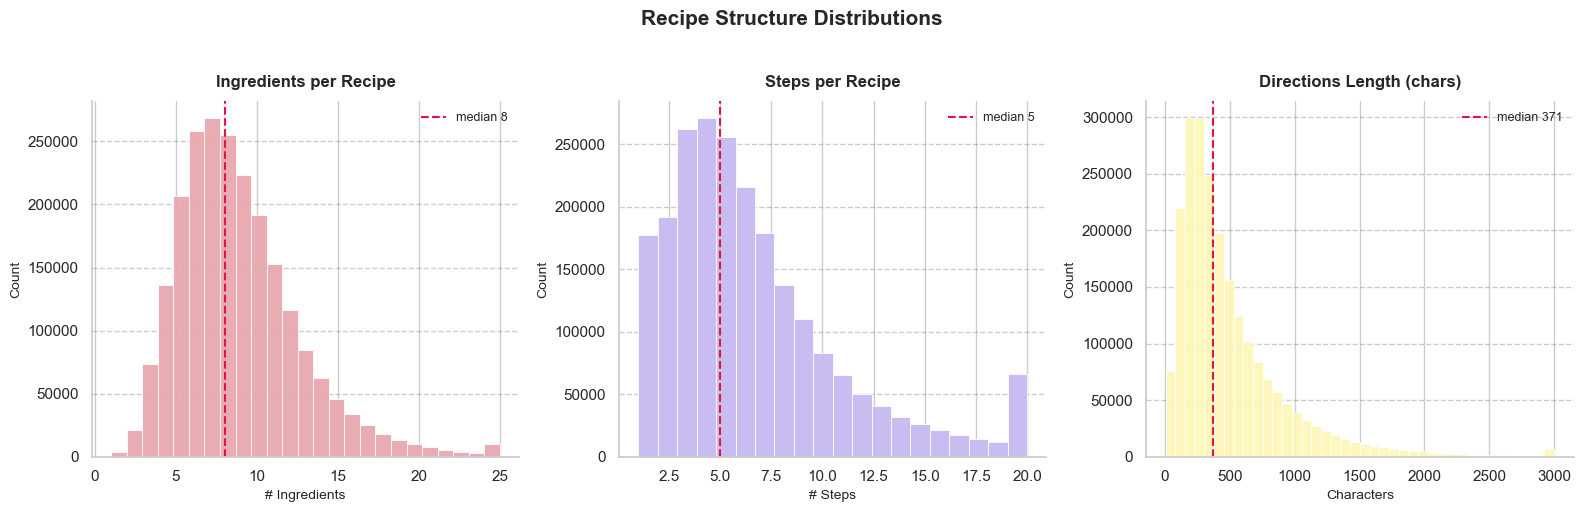

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="white")
fig.suptitle("Recipe Structure Distributions", fontsize=15, fontweight="bold", y=1.02)

specs = [
    ("n_ingredients", 25, PRES["pink"],   "Ingredients per Recipe",      "# Ingredients"),
    ("n_steps",       20, PRES["purple"],  "Steps per Recipe",            "# Steps"),
    ("directions_char_len", 40, PRES["yellow"], "Directions Length (chars)", "Characters"),
]
clips = [25, 20, 3000]

for ax, (col, bins, color, title, xlabel), clip in zip(axes, specs, clips):
    data = df[col].clip(upper=clip)
    ax.hist(data, bins=bins, color=color, edgecolor="white", linewidth=0.6, alpha=0.95)
    ax.axvline(data.median(), color=PRES["red"], linestyle="--", linewidth=1.5,
               label=f"median {data.median():.0f}")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="gray")
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Top 30 most common ingredients (NER)

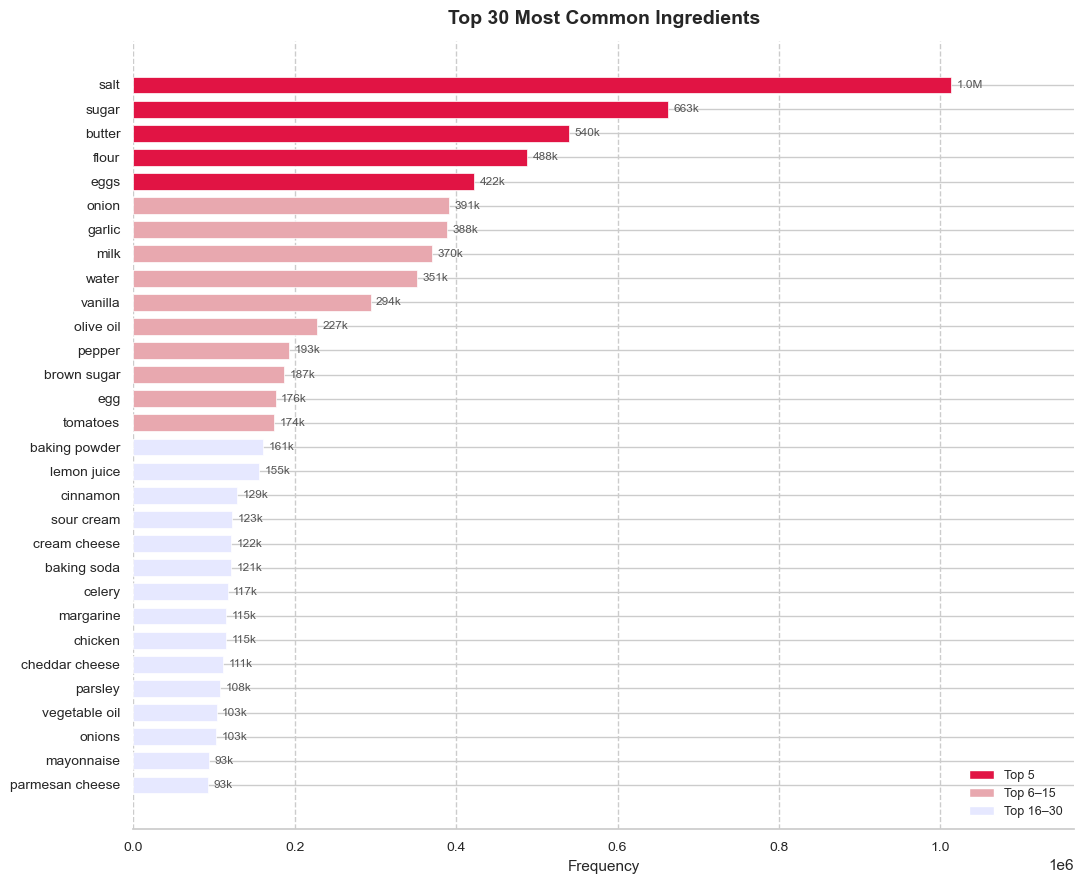

In [64]:
all_ner = [ing.lower() for sublist in df["ner_list"] for ing in sublist]
top_ingredients = pd.Series(Counter(all_ner)).nlargest(30)

colors = [PRES["red"] if i < 5 else PRES["pink"] if i < 15 else PRES["lavender"]
          for i in range(30)]

fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")
bars = ax.barh(
    top_ingredients.index[::-1],
    top_ingredients.values[::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)
ax.bar_label(bars, fmt=lambda x: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k",
             padding=4, fontsize=8.5, color="#555")
ax.set_title("Top 30 Most Common Ingredients", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Frequency", fontsize=11)
ax.set_xlim(0, top_ingredients.max() * 1.15)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False, labelsize=10)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PRES["red"],     label="Top 5"),
    Patch(facecolor=PRES["pink"],    label="Top 6–15"),
    Patch(facecolor=PRES["lavender"],label="Top 16–30"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

## Ingredient Co-occurrence Analysis

In [65]:
from itertools import combinations

# Restrict to top 50 ingredients to keep co-occurrence tractable
TOP_N = 50
top50 = set(pd.Series(Counter(all_ner)).nlargest(TOP_N).index)

cooccur = Counter()
for ing_list in df["ner_list"]:
    tokens = [i.lower() for i in ing_list if i.lower() in top50]
    for pair in combinations(sorted(set(tokens)), 2):
        cooccur[pair] += 1

print(f"Unique co-occurring pairs (within top {TOP_N}): {len(cooccur):,}")
print("\nTop 15 most co-occurring pairs:")
for pair, count in cooccur.most_common(15):
    print(f"  {pair[0]:25s} + {pair[1]:25s}  →  {count:,}")

Unique co-occurring pairs (within top 50): 1,225

Top 15 most co-occurring pairs:
  flour                     + salt                       →  301,580
  salt                      + sugar                      →  295,045
  flour                     + sugar                      →  254,631
  butter                    + salt                       →  252,491
  eggs                      + salt                       →  231,566
  eggs                      + sugar                      →  212,937
  onion                     + salt                       →  211,537
  garlic                    + salt                       →  206,318
  eggs                      + flour                      →  197,298
  butter                    + flour                      →  196,653
  sugar                     + vanilla                    →  189,927
  butter                    + sugar                      →  188,545
  milk                      + salt                       →  177,045
  salt                      + wate

### Co-occurrence Heatmap (Top 20 ingredients)

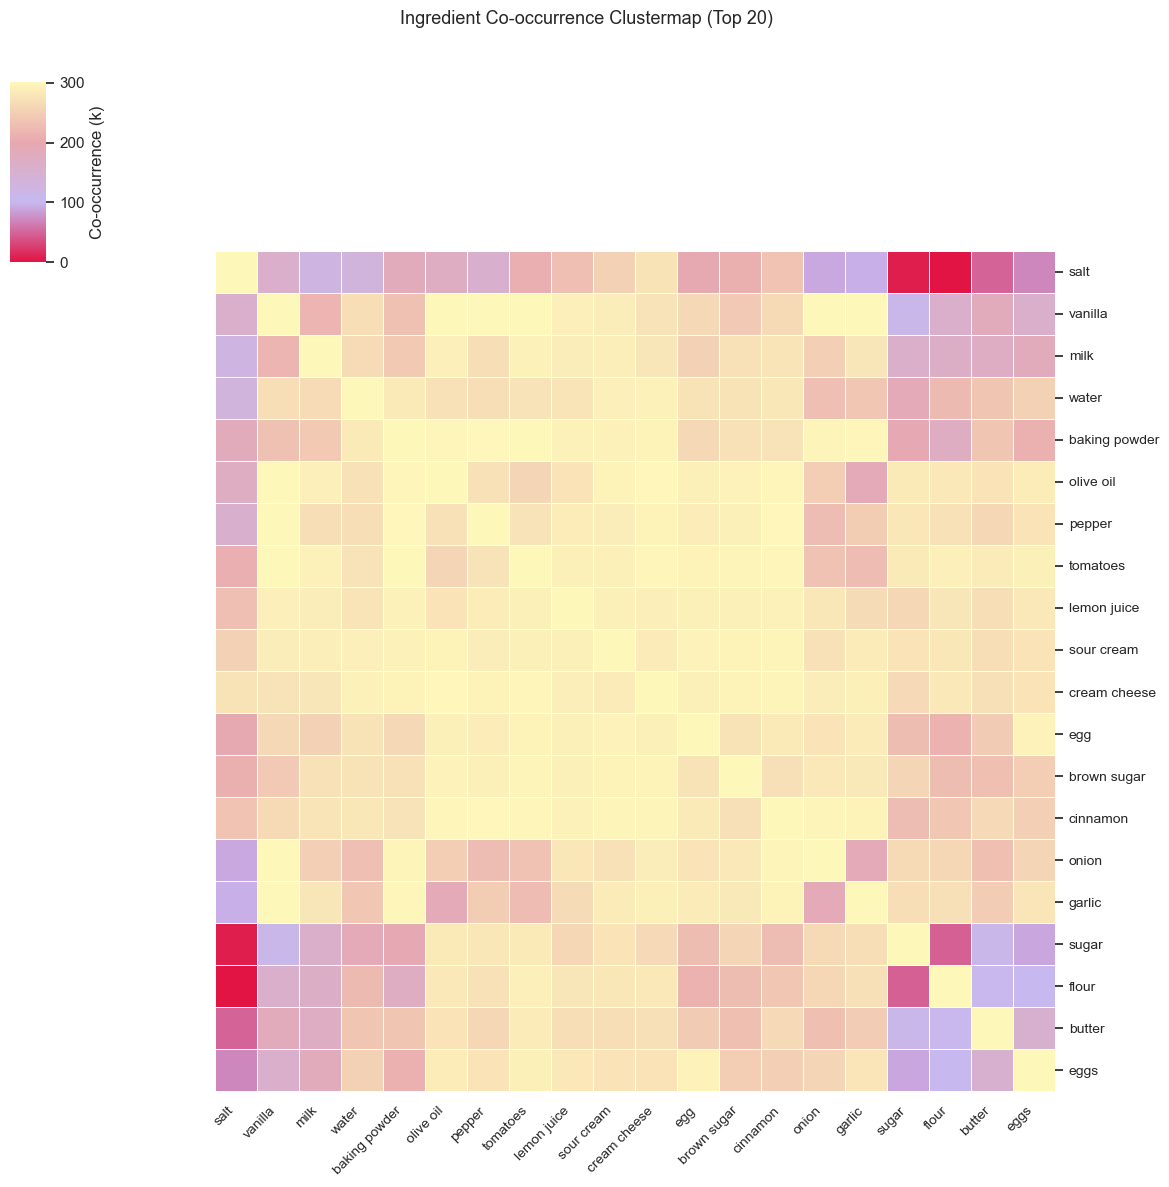

In [66]:
top20 = list(pd.Series(Counter(all_ner)).nlargest(20).index)

matrix = pd.DataFrame(0, index=top20, columns=top20, dtype=float)
for (a, b), count in cooccur.items():
    if a in matrix.index and b in matrix.columns:
        matrix.loc[a, b] = count / 1000
        matrix.loc[b, a] = count / 1000

# Convert similarity → distance so clustering linkage works correctly
max_val = matrix.values.max()
distance_matrix = max_val - matrix

g = sns.clustermap(
    distance_matrix,
    cmap=CMAP_r,
    figsize=(12, 12),
    linewidths=0.4,
    linecolor="white",
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    cbar_kws={"label": "Co-occurrence (k)"},
    xticklabels=True,
    yticklabels=True,
    method="average",
    tree_kws={"linewidths": 0},
)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=10)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
g.figure.suptitle("Ingredient Co-occurrence Clustermap (Top 20)", fontsize=13, y=1.01)
plt.show()

### Top Co-occurring Pairs (Bar Chart)

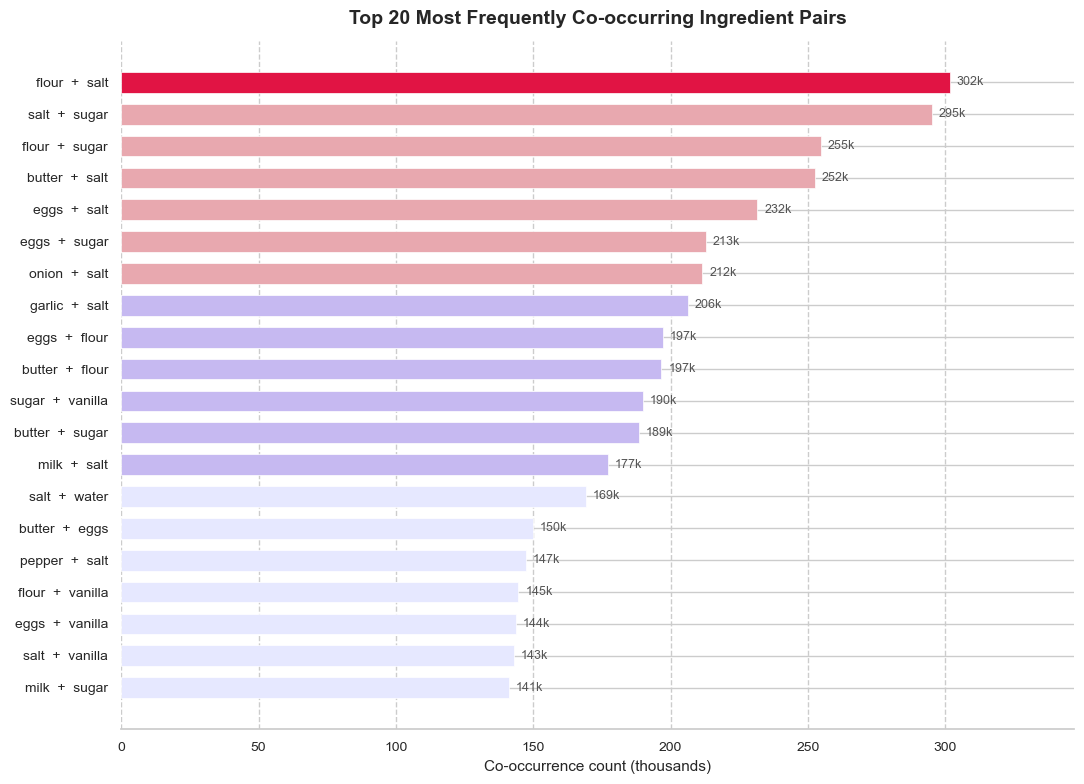

In [67]:
top_pairs = cooccur.most_common(20)
labels = [f"{a}  +  {b}" for (a, b), _ in top_pairs]
values = [c / 1000 for _, c in top_pairs]

bar_colors = [PRES["red"] if v == max(values) else PRES["pink"] if v > np.percentile(values, 66)
              else PRES["purple"] if v > np.percentile(values, 33) else PRES["lavender"]
              for v in values]

fig, ax = plt.subplots(figsize=(11, 8), facecolor="white")
bars = ax.barh(labels[::-1], values[::-1], color=bar_colors[::-1], height=0.65,
               edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.0fk", padding=5, fontsize=9, color="#555")
ax.set_xlabel("Co-occurrence count (thousands)", fontsize=11)
ax.set_title("Top 20 Most Frequently Co-occurring Ingredient Pairs", fontsize=14,
             fontweight="bold", pad=12)
ax.set_xlim(0, max(values) * 1.15)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False, labelsize=10)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
## Summary of Results 
### Distributions (Ingredient Count, Steps, Directions Length)
Most recipes in this dataset are pretty simple. The typical recipe uses around **8 ingredients**, has about **5 steps**, and directions that are roughly **370 characters** long. But the distributions are skewed right, meaning a small number of recipes are extremely long. Some have over 400 ingredients and 164 steps

---

### Top 30 Most Common Ingredients
The most common ingredients are exactly what you'd expect from home cooking — **salt, sugar, butter, flour, and eggs** take the top five spots. This tells us the dataset is heavily dominated by everyday  home cooking and baking. One data quality issue is "egg" and "eggs" are counted as two separate ingredients, and same with "onion" and "onions."

---

### Co-occurrence Clustermap (Top 20 Ingredients)
This chart groups ingredients by how often they appear together in the same recipe. Two clear clusters emerge on their own, without us telling the model anything:

- **Baking cluster** — sugar, butter, flour, eggs, vanilla, brown sugar, and baking powder all land together. These ingredients travel as a pack.
- **Savory cluster** — garlic, onion, olive oil, pepper, and tomatoes group on the other side.

The interesting one is **salt** — it shows up in almost everything. Baking recipes use it, savory recipes use it.

---

### Top Co-occurring Pairs (Bar Chart)
The bar chart shows the strongest ingredient pairings by raw count. **Salt + butter** and **salt + sugar** are at the top, which again reflects salt's universal presence. After that you see the baking cluster dominate — **butter + flour**, **butter + sugar**, **eggs + butter** all appear in hundreds of thousands of recipes together. The savory pairs (garlic + onion, garlic + olive oil) show up further down the list with noticeably smaller counts, confirming that the baking half of the dataset is larger and more consistent than the savory half.

---


**Overall, the dataset is dominated by baking.** Baking recipes are more numerous, use more consistent ingredient combinations, and co-occur more tightly. Any model trained on this data will be better at baking recipes than savory ones.
